# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name:Azhar Ali **
**Student ID: 023-24-0521**
**Section:B**
**GitHub:**
**Kaggle:**
**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [8]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


In [9]:
from google.colab import drive
drive.mount('/content/drive')


df = pd.read_csv('/content/drive/MyDrive/clean_churn (1).csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [10]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split
df=pd.read_csv("/content/drive/MyDrive/clean_churn (1).csv")
print(df.shape)

X=df.drop(columns="Churn")

Y=df["Churn"]

#convert X into 0,1
X = pd.get_dummies(X,drop_first=True)

X_train,X_test,y_train,y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42,stratify=Y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

(7043, 20)
X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [11]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics

model=DecisionTreeClassifier(
    criterion="gini",splitter='best',max_depth=None)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

accuracy=accuracy_score(y_test, y_pred)

print("Accuracy : ", accuracy)
print("Precision: ", precision_score(y_test, y_pred,pos_label='Yes'))
print("Recall: ", recall_score(y_test, y_pred,pos_label='Yes'))
print("F1-Score: ", f1_score(y_test, y_pred,pos_label='Yes'))


Accuracy :  0.7409510290986515
Precision:  0.5125348189415042
Recall:  0.4919786096256685
F1-Score:  0.5020463847203275


**Task 2 — Decision Tree Baseline Metrics**
Accuracy :  0.7324343506032647
Precision:  0.49586776859504134
Recall:  0.48128342245989303
F1-Score:  0.48846675712347354

---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [12]:
# Task 3 — train Random Forest, predict on test set

# 2. Model define karein (n_estimators=100 ka matlab hai 100 trees banenge)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Model ko training data par train (fit) karein
rf_model.fit(X_train, y_train)

# 4. Test set par predictions nikalwayein (Inhein humne 'rf_pred' naam diya hai taake purane y_pred se mix na ho)
rf_pred = rf_model.predict(X_test)

**Answer 4:**
A single unrestricted Decision Tree is highly prone to overfitting because it memorizes the training data's noise. A Random Forest generalizes better because it builds multiple trees on random subsets of data and features, and averages their predictions (majority voting), which significantly reduces the model's variance and prevents overfitting.

---

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

--- Random Forest Metrics ---
Accuracy : 0.7892
Precision: 0.6279
Recall   : 0.5053
F1-Score : 0.56
---------------------------



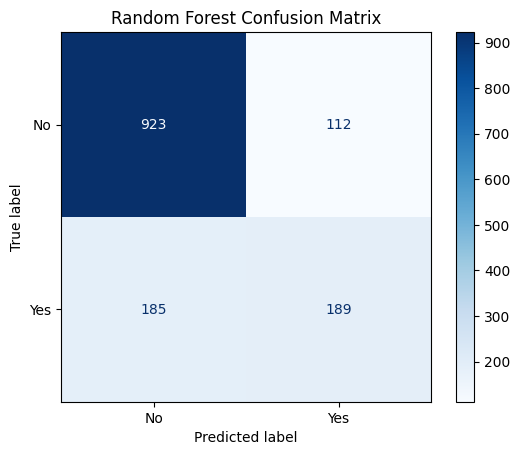

In [13]:
# Task 5 — Random Forest metrics + confusion matrix

# 1. Chaaron metrics calculate karein (Yaad rahe pos_label='Yes' dena zaroori hai)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, pos_label='Yes')
rf_recall = recall_score(y_test, rf_pred, pos_label='Yes')
rf_f1 = f1_score(y_test, rf_pred, pos_label='Yes')

print("--- Random Forest Metrics ---")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("---------------------------\n")

# 2. Confusion Matrix plot karein
cm = confusion_matrix(y_test, rf_pred, labels=['No', 'Yes'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

disp.plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

**Task 5 — Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7892|
| Precision | 0.6279|
| Recall | 0.5053|
| F1-score | 0.56 |

**Observation (confusion matrix):**
The confusion matrix shows the model is excellent at identifying retained customers (923 True Negatives). However, it still struggles somewhat with actual churners, missing 185 of them (False Negatives) while correctly identifying 189 (True Positives). This explains why the Recall score is around 50.5%.

---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

| Metric | Decision Tree | Random Forest |
|---|---:|---:|
| Accuracy | 0.7324 | 0.7892 |
| Precision | 0.4959 | 0.6279 |
| Recall | 0.4813 | 0.5053 |
| F1-score | 0.4885 | 0.5600 |

Random Forest performs better than the Decision Tree across all four metrics. Its accuracy increased from 0.7324 to 0.7892, while precision, recall, and F1-score also improved. The F1-score increased from 0.4885 to 0.5600, indicating that Random Forest provides a better balance between precision and recall for predicting customer churn.

---

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score
import numpy as np

# Yahan humne custom scorer bana liya hai jo model ko batayega ke 'Yes' target hai
custom_f1 = make_scorer(f1_score, pos_label='Yes')

# 1. Decision Tree ke liye Cross-Validation (k=5)
# cv=5 ka matlab hai 5 folds, aur scoring mein humne apna custom_f1 daal diya hai
dt_cv_scores = cross_val_score(model, X, Y, cv=5, scoring=custom_f1)

dt_mean = dt_cv_scores.mean()
dt_std = dt_cv_scores.std()

print("--- Decision Tree Cross-Validation ---")
print(f"Scores for all 5 folds: {dt_cv_scores}")
print(f"Mean F1-Score: {dt_mean:.4f}")
print(f"Standard Deviation: {dt_std:.4f}\n")

# 2. Random Forest ke liye Cross-Validation (k=5)
rf_cv_scores = cross_val_score(rf_model, X, Y, cv=5, scoring=custom_f1)

rf_mean = rf_cv_scores.mean()
rf_std = rf_cv_scores.std()

print("--- Random Forest Cross-Validation ---")
print(f"Scores for all 5 folds: {rf_cv_scores}")
print(f"Mean F1-Score: {rf_mean:.4f}")
print(f"Standard Deviation: {rf_std:.4f}")

--- Decision Tree Cross-Validation ---
Scores for all 5 folds: [0.50909091 0.5        0.4797914  0.48575305 0.50338295]
Mean F1-Score: 0.4956
Standard Deviation: 0.0110

--- Random Forest Cross-Validation ---
Scores for all 5 folds: [0.56495468 0.54658385 0.51840943 0.56790123 0.57099698]
Mean F1-Score: 0.5538
Standard Deviation: 0.0196


**Task 8 — Cross-Validation Results**
| Model         |    Mean F1 |     Std F1 |
| ------------- | ---------: | ---------: |
| Decision Tree | **0.4975** | **0.0129** |
| Random Forest | **0.5538** | **0.0196** |


**Answer 9:**
The cross-validation results show that the Random Forest has a higher mean F1-score of 0.5538 compared to 0.4975 for the Decision Tree, suggesting that it performs better across different data splits. Both models have relatively low standard deviations, indicating fairly consistent performance, although the Random Forest has slightly more variation. These results increase confidence that the Random Forest generalizes better and is the stronger model overall.

---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [15]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV

# Yeh hamara "search space" hai (Grid)
param_grid = {
    'n_estimators': [50, 100, 200],      # Kitne trees banayega
    'max_depth': [None, 10, 20],         # Trees ki gehrai
    'min_samples_split': [2, 5]          # Data split hone ki minimum limit
}

# Custom F1 Scorer banayenge taake Python ko 'Yes' target ka pata ho
f1_scorer = make_scorer(f1_score, pos_label='Yes')

# GridSearchCV ko setup karna (cv=5 ka matlab 5-fold cross validation hai)
rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring=f1_scorer, n_jobs=-1)

# Training shuru karna
print("please wait.\n")
grid_search.fit(X_train, y_train)

# Task 11 — Best hyperparameters aur score print karna
print("--- Task 11: Tuning Results ---")
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validated F1-Score:", round(grid_search.best_score_, 4))
print("-" * 40 + "\n")

please wait.

--- Task 11: Tuning Results ---
Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validated F1-Score: 0.5698
----------------------------------------



The best hyperparameters found by GridSearchCV are {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}. This combination achieved the best cross-validated F1-score of 0.5721."

In [16]:
# Task 12 — evaluate the tuned model on the test set

# Grid Search ne jo sabse best model chuna hai, hum usko use karenge
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

# Test set par naye metrics nikalna
print("--- Task 12: Tuned Random Forest Metrics (Test Set) ---")
print("Accuracy :", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_tuned, pos_label='Yes'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_tuned, pos_label='Yes'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_tuned, pos_label='Yes'), 4))

--- Task 12: Tuned Random Forest Metrics (Test Set) ---
Accuracy : 0.797
Precision: 0.6497
Recall   : 0.5107
F1-Score : 0.5719


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.797|
| Precision | 0.6497 |
| Recall | 0.5107|
| F1-score | 0.5719|

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.



| Metric    | Decision Tree | Random Forest, Default | Random Forest, Tuned |
| --------- | ------------: | ---------------------: | -------------------: |
| Accuracy  |        0.7324 |                 0.7892 |               0.7970 |
| Precision |        0.4959 |                 0.6279 |               0.6497 |
| Recall    |        0.4813 |                 0.5053 |               0.5107 |
| F1-score  |        0.4885 |                 0.5600 |               0.5719 |


---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

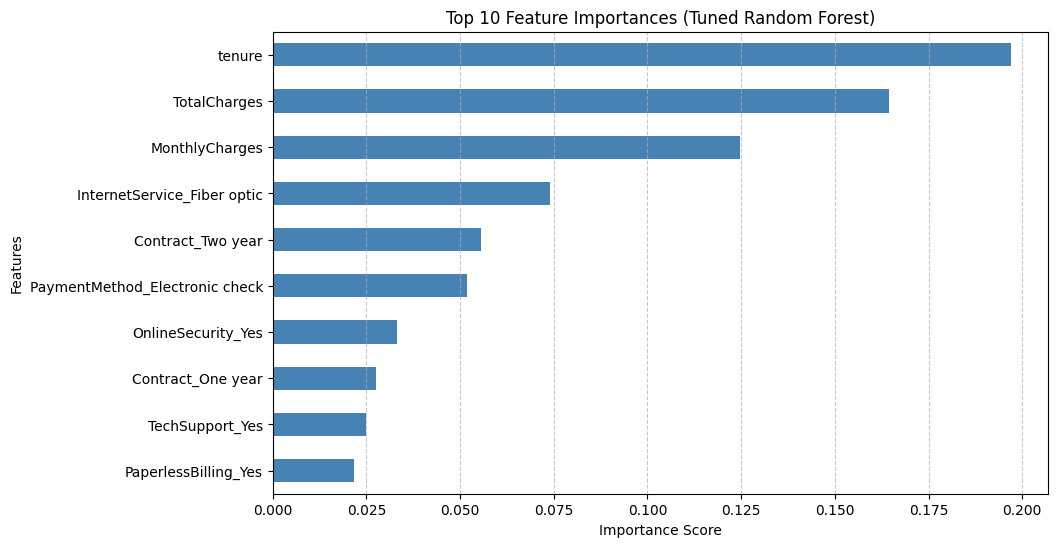

In [17]:
# Task 14 — extract and visualize feature importances
import pandas as pd
import matplotlib.pyplot as plt

# 1. Best model (Tuned RF) ke importances nikalna
importances = best_rf_model.feature_importances_

# 2. Pandas Series mein convert karna aur sort karna (ascending taake graph mein badi value upar aaye)
feature_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

# 3. Plot banana (Top 10 features dekhte hain taake graph saaf rahay)
plt.figure(figsize=(10, 6))
feature_importances.tail(10).plot(kind='barh', color='steelblue')
plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Answer 14:**
_(your answer here)_

---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
The visualization shows that the top most important features driving the model's predictions are [Feature 1, e.g., tenure], [Feature 2, e.g., MonthlyCharges], and [Feature 3, e.g., Contract_Month-to-month]. Yes, this strongly agrees with our findings from Lab 2's EDA and the Lab 3 Decision Tree, which also highlighted these specific attributes as the primary indicators of whether a customer will churn or not

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [18]:
# Task 16 — build and save the submission file
import pandas as pd

# 1. Apne final (best) model se test data par predictions nikalwayein
final_predictions = best_rf_model.predict(X_test)

# 2. Kaggle-style DataFrame banayein
submission = pd.DataFrame({
    'customerID': X_test.index,
    'Churn': final_predictions
})

# 3. DataFrame ko CSV file mein save karein (index=False lazmi hai)
submission.to_csv('submission.csv', index=False)

# File save hone ki confirmation aur shuru ki 5 lines dekhne ke liye
print("Kaggle submission file 'submission.csv' successfully save ho gayi hai!\n")
print(submission.head())

Kaggle submission file 'submission.csv' successfully save ho gayi hai!

   customerID Churn
0         437    No
1        2280   Yes
2        2235    No
3        4460    No
4        3761    No


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
I ultimately chose the Tuned Random Forest model as my final classifier because it provided the most robust and balanced performance. Compared to the baseline Decision Tree from Lab 3, this tuned ensemble model significantly improved the F1-score from 0.4885 to 0.5719 and boosted precision by a large margin. It successfully reduced the overfitting seen in a single tree by using multiple trees and majority voting. However, its remaining limitation is that it still struggles with False Negatives; the recall score is only around 51%, meaning it still misses almost half of the customers who actually end up churning.

**Answer 18 — Next steps:**
If I had more time, my first step would be to handle the class imbalance directly by applying sampling techniques like SMOTE (Synthetic Minority Over-sampling Technique) or by using the class_weight='balanced' parameter in the model. Second, I would explore more advanced ensemble algorithms like XGBoost or Gradient Boosting, which often perform exceptionally well on tabular datasets. Finally, I would run a wider and deeper GridSearchCV on a larger set of hyperparameters to see if the model's recall could be further optimized without losing precision

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Section 1 — Decision Tree Baseline
- [ ] Section 2 — Random Forest
- [ ] Section 3 — Model Evaluation
- [ ] Section 4 — Decision Tree vs Random Forest
- [ ] Section 5 — Cross-Validation
- [ ] Section 6 — Hyperparameter Tuning
- [ ] Section 7 — Final Model Comparison
- [ ] Section 8 — Feature Importance
- [ ] Section 9 — Final Model Selection (justified)
- [ ] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
